# Лабораторная работа №5

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification, make_blobs

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
RNG_SEED = 42
np.random.seed(RNG_SEED)

## Загрузка и подготовка данных

### Загрузка датасета для задачи классификации

In [6]:
df_wine = pd.read_csv('../data/final_data_wine.csv', index_col=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [7]:
df_wine.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5974 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5974 non-null   float64
 1   volatile acidity      5974 non-null   float64
 2   citric acid           5974 non-null   float64
 3   residual sugar        5974 non-null   float64
 4   chlorides             5974 non-null   float64
 5   free sulfur dioxide   5974 non-null   float64
 6   total sulfur dioxide  5974 non-null   float64
 7   density               5974 non-null   float64
 8   pH                    5974 non-null   float64
 9   sulphates             5974 non-null   float64
 10  alcohol               5974 non-null   float64
 11  quality               5974 non-null   int64  
 12  type                  5974 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 653.4 KB


### Выделеение целевого признака и предиктора, разделение на выборки

In [8]:
X_wine = df_wine.drop(columns=['type'])
y_wine = df_wine['type']
print(X_wine.shape, y_wine.shape)
print(y_wine.value_counts())

(5974, 12) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


### Разделение данных

In [9]:
X_temp_wine, X_test_wine, y_temp_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=RNG_SEED)
X_train_wine, X_val_wine, y_train_wine, y_val_wine = train_test_split(X_temp_wine, y_temp_wine, test_size=0.25, stratify=y_temp_wine, random_state=RNG_SEED)

print(X_train_wine.shape, X_val_wine.shape, X_test_wine.shape)
print(y_train_wine.shape, X_val_wine.shape, y_test_wine.shape)


(3584, 12) (1195, 12) (1195, 12)
(3584,) (1195, 12) (1195,)


### Балансировка

In [10]:
y_train_wine.value_counts()

type
0    2745
1     839
Name: count, dtype: int64

In [13]:
oversample = SMOTE()

X_train_bal_wine, y_train_bal_wine = oversample.fit_resample(X_train_wine, y_train_wine)
y_train_bal_wine.value_counts()

type
0    2745
1    2745
Name: count, dtype: int64

### Созданине синтетических данных

In [106]:
clf_3, y_clf_3 = make_classification(
    n_samples=600, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0,
    n_clusters_per_class=1, 
    n_classes=3, 
    flip_y=0, 
    class_sep=2.0,
    random_state=RNG_SEED
)

clf_4, y_clf_4 = make_classification(
    n_samples=700, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0,
    n_clusters_per_class=1, 
    n_classes=4, 
    flip_y=0, 
    class_sep=1.8,
    random_state=RNG_SEED+1
)

clf_5, y_clf_5 = make_classification(
    n_samples=500, 
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1, 
    n_classes=4,
    flip_y=0,
    class_sep=2.0,
    random_state=RNG_SEED+2132
)

synth_clf = {
    'make_clf_3_classes': (clf_3, y_clf_3),
    'make_clf_4_classes': (clf_4, y_clf_4),
    'make_clf_5_classes': (clf_5, y_clf_5)
}

In [88]:
blobs_4, y_blobs_4 = make_blobs(
    n_samples=600, 
    centers=4, 
    n_features=2, 
    cluster_std=1.0, 
    random_state=RNG_SEED
)

blobs_6, y_blobs_6 = make_blobs(
    n_samples=800, 
    centers=6, 
    n_features=2, 
    cluster_std=0.6, 
    random_state=RNG_SEED
)

synth_blobs = {
    'make_blobs_4_centers': (blobs_4, y_blobs_4),
    'make_blobs_6_centers': (blobs_6, y_blobs_6)
}   

In [107]:
synth_data = { **synth_clf, **synth_blobs}

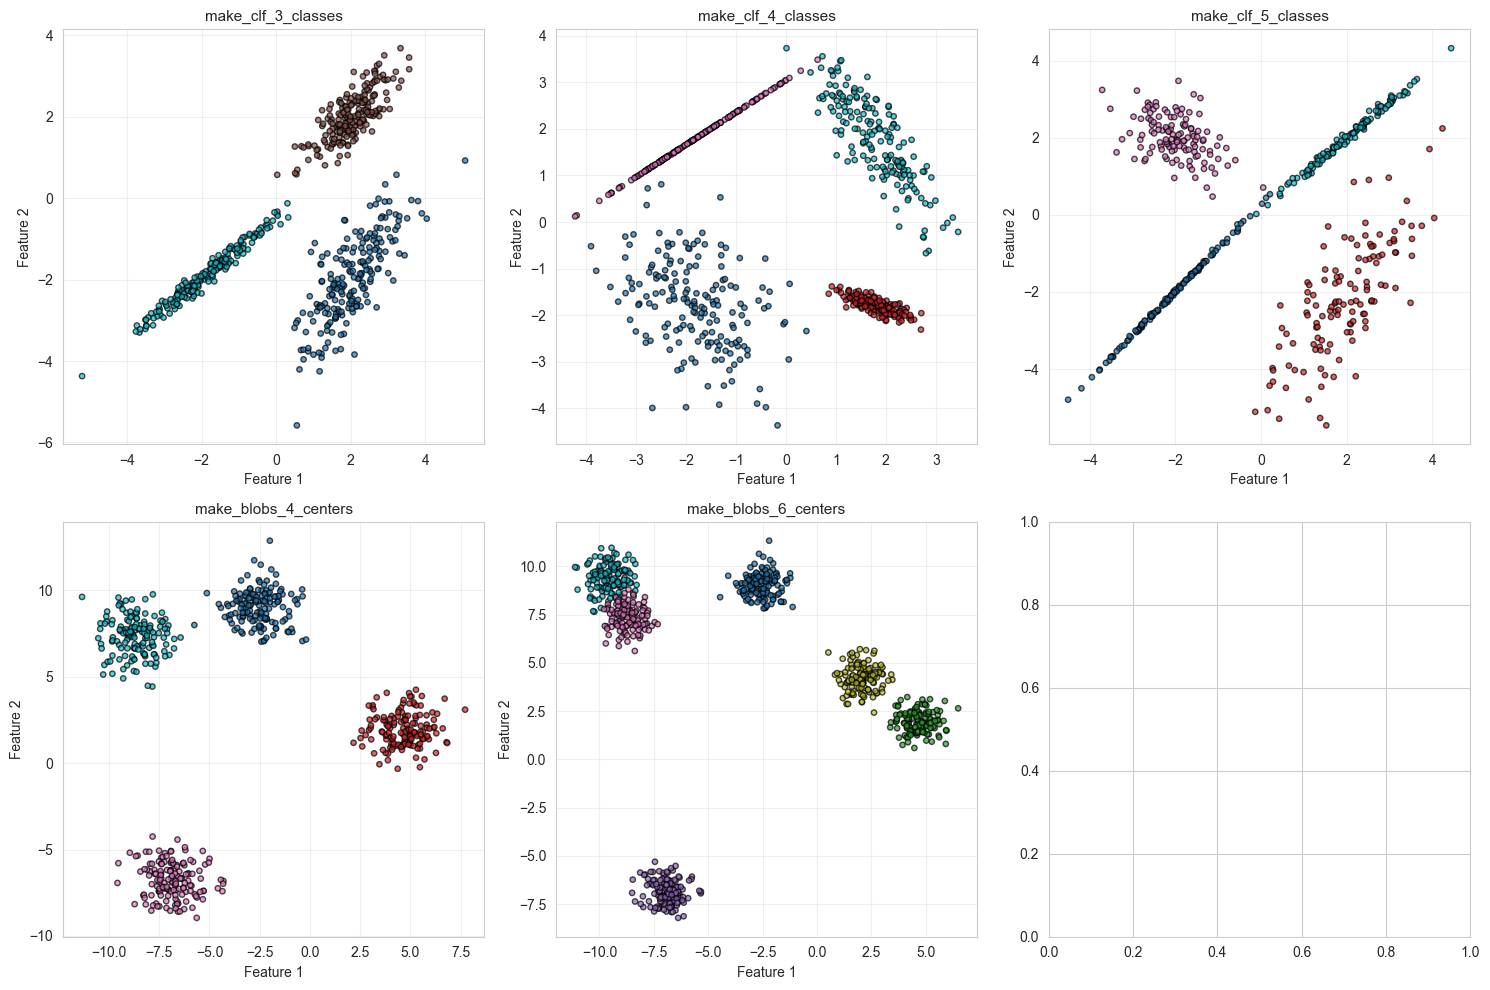

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, (X, y)) in enumerate(synth_data.items()):
    axes[i].scatter(X[:, 0], X[:, 1], c=y, cmap='tab10', s=15, edgecolor='k', alpha=0.7)
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()